**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Tutorial 4
## Face Detection with MLPs

In this tutorial you will train an MLP to detect whether there is a face in a small image patch.

First we need to initialize Python.  Run the below cell.

In [4]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
# from numpy import *
from sklearn import *
import os
import zipfile
import fnmatch
import skimage.io
import skimage.color
import skimage.transform
from scipy import ndimage
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Next we will load PyTorch.

In [5]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [6]:
import sys
print("Python:", sys.version, "Torch", torch.__version__)
from typing import List

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0] Torch 2.8.0+cu126


##  Loading Data and Pre-processing
Next we need to load the images.  Download `faces.zip`, and place it in the same directory as this ipynb file.  **Do not unzip it.** Then run the following cell to load the images.

In [8]:
imgdata = {'train':[], 'test':[]}
classes = {'train':[], 'test':[]}

# the dataset is too big, so subsample the training and test sets...
# reduce training set by a factor of 4
train_subsample = 1
train_counter = [0, 0]
# maximum number of samples in each class for test set
test_maxsample = 472
test_counter = [0, 0]

# load the zip file
filename = 'faces.zip'
zfile = zipfile.ZipFile(filename, 'r')

for name in zfile.namelist():
    # check file name matches
    if fnmatch.fnmatch(name, "faces/*/*/*.png"):

        # filename is : faces/train/face/fname.png
        (fdir1, fname)  = os.path.split(name)     # get file name
        (fdir2, fclass) = os.path.split(fdir1) # get class (face, nonface)
        (fdir3, fset)   = os.path.split(fdir2) # get training/test set
        # class 1 = face; class 0 = non-face
        myclass = int(fclass == "face")

        loadme = False
        if fset == 'train':
            if (train_counter[myclass] % train_subsample) == 0:
                loadme = True
            train_counter[myclass] += 1
        elif fset == 'test':
            if test_counter[myclass] < test_maxsample:
                loadme = True
            test_counter[myclass] += 1

        if (loadme):
            # open file in memory, and parse as an image
            myfile = zfile.open(name)
            #img = matplotlib.image.imread(myfile)
            img = skimage.io.imread(myfile, as_gray=True)
            myfile.close()

            # append data
            imgdata[fset].append(img)
            classes[fset].append(myclass)


zfile.close()
imgsize = img.shape

print(len(imgdata['train']))
print(len(imgdata['test']))
trainclass2start = sum(classes['train'])

6977
944


Next we will convert the list of images into a block (array) of images for easier processing.

In [9]:
# convert list to numpy array
trainY = np.asarray(classes['train'])
testY  = np.asarray(classes['test'])

# convert list of ndarray to ndarray
trainI = np.asarray(imgdata['train'], dtype=np.float32).reshape((6977,19,19,1))
testI  = np.asarray(imgdata['test'], dtype=np.float32).reshape((944,19,19,1))

# cleanup memory
# del imgdata

# shuffle the data (since it is in order by class)
np.random.seed(123)
inds1 = np.random.permutation(len(trainI)).tolist()
inds2 = np.random.permutation(len(testI)).tolist()
trainY = trainY[inds1]
testY  = testY[inds2]
trainI = trainI[inds1]
testI = testI[inds2]

print(trainI.shape)
print(testI.shape)

(6977, 19, 19, 1)
(944, 19, 19, 1)


Each image is a 19x19x1 array of pixel values.  The last dimension is the number of channels in the image - in this case the image is grayscale, so there is only 1 channel.  Run the below code to show an example:

(19, 19)


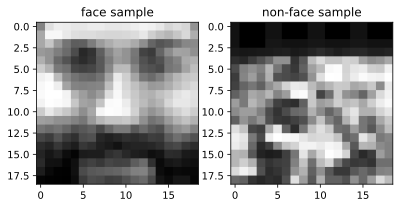

In [10]:
print(img.shape)
plt.subplot(1,2,1)
plt.imshow(np.squeeze(trainI[1]), cmap='gray', interpolation='nearest')
plt.title("face sample")
plt.subplot(1,2,2)
plt.imshow(np.squeeze(trainI[2]), cmap='gray', interpolation='nearest')
plt.title("non-face sample")
plt.show()

Run the below code to show more images!

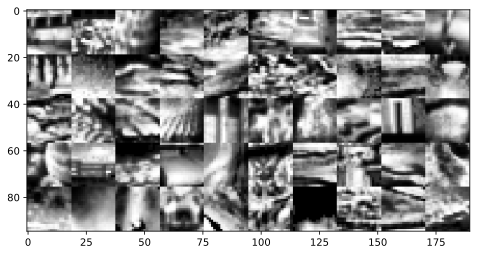

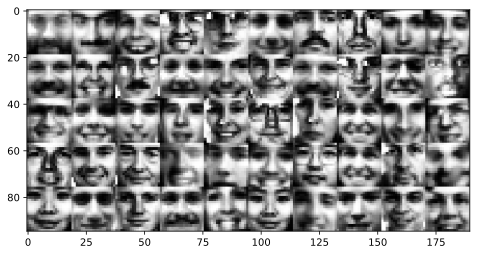

In [11]:
# function to make an image montage
def image_montage(X, imsize=None, maxw=10):
    """X can be a list of images, or a matrix of vectorized images.
      Specify imsize when X is a matrix."""
    tmp = []
    numimgs = len(X)

    # create a list of images (reshape if necessary)
    for i in range(0,numimgs):
        if imsize != None:
            tmp.append(X[i].reshape(imsize))
        else:
            tmp.append(np.squeeze(X[i]))

    # add blanks
    if (numimgs > maxw) and (np.mod(numimgs, maxw) > 0):
        leftover = maxw - np.mod(numimgs, maxw)
        meanimg = 0.5*(X[0].max()+X[0].min())
        for i in range(0,leftover):
            tmp.append(ones(tmp[0].shape)*meanimg)

    # make the montage
    tmp2 = []
    for i in range(0,len(tmp),maxw):
        tmp2.append( np.hstack(tmp[i:i+maxw]) )
    montimg = np.vstack(tmp2)
    return montimg

# show images in a plot
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    # nc is the number of columns
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            plt.imshow(cur_W,cmap='gray', interpolation='nearest')
            if titles is not None:
                if isinstance(titles, str):
                    plt.title(titles.format(idx))
                else:
                    plt.title(titles[idx])

            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]):
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()

# show a few images
plt.figure(figsize=(9,4))
plt.imshow(image_montage(trainI[trainY==0][0:50]), cmap='gray', interpolation='nearest')
plt.show()

plt.figure(figsize=(9,4))
plt.imshow(image_montage(trainI[trainY==1][0:50]), cmap='gray', interpolation='nearest')
plt.show()

Next we will generate the training/validation set from the training data.

In [12]:
# generate fixed validation set of 10% of the training set
vtrainI, validI, vtrainY, validY = \
  model_selection.train_test_split(trainI, trainY,
  train_size=0.9, test_size=0.1, random_state=4488)

# make validation data
validsetI = (validI, validY)

print(vtrainI.shape)
print(validI.shape)

(6279, 19, 19, 1)
(698, 19, 19, 1)


Here are some useful functions.

In [13]:
def plot_history2(history):
    fig, ax1 = plt.subplots()
    ax1.plot(history['train_loss'], 'r', label="training loss ({:.6f})".format(history['train_loss'][-1]))
    ax1.plot(history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')
    if 'train_acc' in history:
        ax2 = ax1.twinx()
        ax2.plot(history['train_acc'], 'b', label="training acc ({:.4f})".format(history['train_acc'][-1]))
        ax2.plot(history['val_acc'], 'b--', label="validation acc ({:.4f})".format(history['val_acc'][-1]))
        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')
        ax2.tick_params('y', colors='b')

Now let's try a simple logistic regression classifier, trained using pytorch. Since the inputs are images, we will convert the input image into a vector first.

In [14]:
# define the network
class MyModel(nn.Module):
    def __init__(self, input_size: int, output_size: int, hidden_sizes: List[int]):
        super().__init__()
        self.input_size, self.output_size, self.hidden_sizes = input_size, output_size, hidden_sizes
        layers = []
        # for the hidden layers
        prev_size = input_size
        for curr_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, curr_size))  # [bs, hidden_size]
            layers.append(nn.ReLU()) # we use relu activation
            prev_size = curr_size
        # for the output layer
        layers.append(nn.Linear(prev_size, output_size))  # [bs, output_size]
        # layers.append(nn.Softmax(dim=-1))  # we perform softmax at the outside, not here!
        # add to the Module itself
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        t_input = x.view(-1, self.input_size)  # [bs, input_size]
        t_output = self.network(t_input)  # [bs, output_size]
        return t_output

In [15]:
# Early stopping implementation
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = 0.0
        self.early_stop = False

    def __call__(self, current_accuracy):
        if current_accuracy - self.best_accuracy > self.min_delta:
            self.best_accuracy = current_accuracy
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [64]:
# define the training loop
def train_model(model, criterion, train_loader, valid_loader, total_epoch: int, patience: int, optimizer=None):
    # for early stopping
    early_stopping = EarlyStopping(patience=patience)
    # record all the losses and accuracies
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    # all the epochs
    for epoch in range(total_epoch):
        model.train()  # set to training mode
        running_loss = 0.0
        correct = 0
        total = 0
        # loop over the training data
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # 1. Zero the gradients
            outputs = model(inputs)  # 2. Forward pass
            loss = criterion(outputs, labels)  # 3. Calculate the loss
            loss.backward()  # 4. Backward pass
            optimizer.step()  # 5. Optimizer step
            # recordings
            with torch.no_grad():
                running_loss += loss.item()
                predicted = torch.argmax(outputs, -1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        # results for one epoch
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        # Validation
        model.eval()  # set to eval mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predicted = torch.argmax(outputs, -1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        val_loss = val_loss / len(valid_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        # print results
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        if early_stopping(val_acc):
            print("Early stopping triggered")
            break
    return {'train_loss': train_losses, 'train_acc': train_accs, 'val_loss': val_losses, 'val_acc': val_accs}

In [65]:
# get dataset and dataloader
def get_dataloader(t_input, t_output, batch_size=32, shuffle=False):
    t_input, t_output = torch.as_tensor(t_input), torch.as_tensor(t_output)
    dataset = TensorDataset(t_input, t_output)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader

Epoch 1: Train Loss: 0.1351, Train Acc: 0.9451, Val Loss: 0.1050, Val Acc: 0.9642
Epoch 2: Train Loss: 0.0711, Train Acc: 0.9753, Val Loss: 0.0696, Val Acc: 0.9699
Epoch 3: Train Loss: 0.0636, Train Acc: 0.9766, Val Loss: 0.0628, Val Acc: 0.9728
Epoch 4: Train Loss: 0.0588, Train Acc: 0.9777, Val Loss: 0.0670, Val Acc: 0.9785
Epoch 5: Train Loss: 0.0561, Train Acc: 0.9790, Val Loss: 0.0585, Val Acc: 0.9785
Epoch 6: Train Loss: 0.0530, Train Acc: 0.9807, Val Loss: 0.0603, Val Acc: 0.9742
Epoch 7: Train Loss: 0.0508, Train Acc: 0.9815, Val Loss: 0.0657, Val Acc: 0.9670
Epoch 8: Train Loss: 0.0498, Train Acc: 0.9806, Val Loss: 0.0709, Val Acc: 0.9771
Epoch 9: Train Loss: 0.0472, Train Acc: 0.9841, Val Loss: 0.0735, Val Acc: 0.9756
Epoch 10: Train Loss: 0.0467, Train Acc: 0.9828, Val Loss: 0.0601, Val Acc: 0.9785
Epoch 11: Train Loss: 0.0443, Train Acc: 0.9842, Val Loss: 0.0641, Val Acc: 0.9756
Epoch 12: Train Loss: 0.0441, Train Acc: 0.9842, Val Loss: 0.0545, Val Acc: 0.9742
Epoch 13: Tra

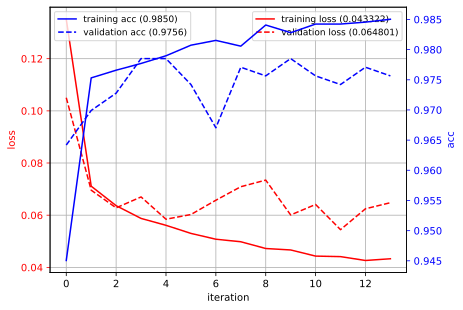

In [67]:
# initialize random seed
torch.manual_seed(4487)
np.random.seed(4487)
random.seed(4487)

# trying a simple logistic regression
model = MyModel(input_size=19*19, output_size=2, hidden_sizes=[])  # one layer model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(vtrainI, vtrainY, batch_size=50, shuffle=True)  # data loaders
val_loader = get_dataloader(validI, validY, batch_size=50)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10, optimizer=optimizer)
# test
plot_history2(history)
predY = model(torch.as_tensor(testI)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

Added baseline: non-linear classifier: SVM with RBF kernel.

In [140]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def prep_X(X):
    X = np.asarray(X, dtype=np.float32)
    if X.max() > 1.0:
        X = X / 255.0
    return X.reshape(len(X), -1)

def prep_y(y):
    y = np.asarray(y).reshape(-1)
    u = set(np.unique(y))
    if u == {1, 2}:    y = y - 1
    elif u == {-1, 1}: y = (y + 1) // 2
    return y.astype(int)

X_tr = prep_X(vtrainI)
y_tr = prep_y(vtrainY)
X_val = prep_X(validI)
y_val = prep_y(validY)
X_te  = prep_X(testI)
y_te  = prep_y(testY)

rbf_svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svc", SVC(kernel="rbf", C=2.0, gamma="scale"))
])

rbf_svm.fit(X_tr, y_tr)
val_pred = rbf_svm.predict(X_val)
te_pred  = rbf_svm.predict(X_te)

print("RBF-SVM val acc :", metrics.accuracy_score(y_val, val_pred))
print("RBF-SVM test acc:", metrics.accuracy_score(y_te, te_pred))


RBF-SVM val acc : 1.0
RBF-SVM test acc: 0.6440677966101694


## Detection using MLP

Train an MLP to classify an image patch as face or not face.  Use  `vtrainI` and `vtrainY` as the training set and `validsetI` as the validation set.  You can try different architectures, and adjust values of the learning rates, number of iterations, early stopping to get a good result.  Use a large batch size (e.g., 50) to speed up the training time.  Remember to monitor the training process.

In [70]:
### INSERT YOUR CODE HERE
class MyMLPModel(nn.Module):
  def __init__(self, input_size: int, output_size: int, hidden_sizes: List[int]):
    super().__init__()
    self.input_size, self.output_size, self.hidden_sizes = input_size, output_size, hidden_sizes

    layers = []
    prev_size = input_size

    for h in hidden_sizes:
      layers.append(nn.Linear(prev_size, h))
      layers.append(nn.ReLU(inplace=True))
      prev_size = h

    layers.append(nn.Linear(prev_size, output_size))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
      t_input = x.view(-1, self.input_size)
      t_output = self.network(t_input)
      return t_output


Epoch 1: Train Loss: 0.1684, Train Acc: 0.9291, Val Loss: 0.0879, Val Acc: 0.9585
Epoch 2: Train Loss: 0.0716, Train Acc: 0.9744, Val Loss: 0.1187, Val Acc: 0.9685
Epoch 3: Train Loss: 0.0536, Train Acc: 0.9782, Val Loss: 0.0514, Val Acc: 0.9785
Epoch 4: Train Loss: 0.0548, Train Acc: 0.9804, Val Loss: 0.0446, Val Acc: 0.9828
Epoch 5: Train Loss: 0.0304, Train Acc: 0.9887, Val Loss: 0.0659, Val Acc: 0.9785
Epoch 6: Train Loss: 0.0342, Train Acc: 0.9866, Val Loss: 0.0329, Val Acc: 0.9871
Epoch 7: Train Loss: 0.0323, Train Acc: 0.9874, Val Loss: 0.0457, Val Acc: 0.9828
Epoch 8: Train Loss: 0.0153, Train Acc: 0.9949, Val Loss: 0.0190, Val Acc: 0.9914
Epoch 9: Train Loss: 0.0163, Train Acc: 0.9939, Val Loss: 0.0303, Val Acc: 0.9900
Epoch 10: Train Loss: 0.0160, Train Acc: 0.9938, Val Loss: 0.0149, Val Acc: 0.9928
Epoch 11: Train Loss: 0.0107, Train Acc: 0.9952, Val Loss: 0.0254, Val Acc: 0.9900
Epoch 12: Train Loss: 0.0142, Train Acc: 0.9947, Val Loss: 0.0794, Val Acc: 0.9685
Epoch 13: Tra

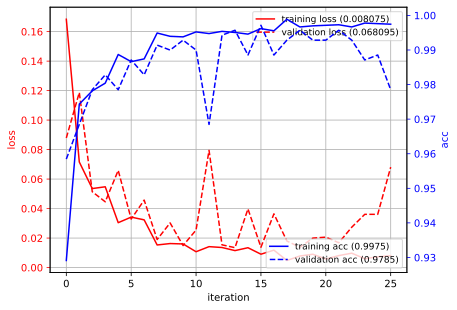

In [137]:
model_mlp = MyMLPModel(input_size=19*19, output_size=2, hidden_sizes=[512, 256, 128])

criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1e-3)

train_loader_mlp = get_dataloader(vtrainI, vtrainY, batch_size=64, shuffle=True)
val_loader_mlp = get_dataloader(validI, validY, batch_size=64)
history_mlp = train_model(model_mlp, criterion_mlp, train_loader_mlp, val_loader_mlp, total_epoch=100, patience=10, optimizer=optimizer_mlp)
plot_history2(history_mlp)

predY_mlp = model_mlp(torch.as_tensor(testI)).argmax(-1)
acc_mlp = metrics.accuracy_score(testY, predY_mlp)
print(f"test accuracy: {acc_mlp}")

logging how the hidden_sizes correlates to the final accuracy
|hidden_size|accuracy (%)|hidden_size|accuracy (%)|hidden_size|accuracy (%)|
|-----|-----|-----|-----|-----|-----|
|8192|63.67|64, 64|60.06|64, 64, 64|58.05|
|4096|64.41|128, 128|62.50|128, 128, 128|63.98|
|2048|61.86|256, 256|62.89|256, 256, 256|60.38|
|1024|62.39|512, 512|62.92|512, 512, 512|59.85|
|512|61.44|1024, 1024|59.22|512, 256, 128|75.53|
|256|58.58|1024, 512|62.29|256, 128, 64|66.31|
|128|60.91|512, 256|63.14|256, 128, 128|64.51|
|256, 128|60.91|128, 64|60.59|128, 128, 64|61.23|


_How does the MLP compare to the linear and non-linear classifiers that you tried in Tutorial 4?_
- **INSERT YOUR ANSWER HERE**
- On this task, logistic regression (linear) reaches about 97.56% validation accuracy but only 55.83% on the test set, showing clear underfitting from its single linear decision boundary; an RBF-SVM achieves 100% on validation yet falls to 64.41% on test, indicating strong overfitting to the val split; the MLP with layers [512, 256, 128] attains roughly 97.85% on validation and 75.53% on test, with smooth loss decay and tracking validation curves, suggesting it learns useful non-linear feature compositions and generalizes best among the three. Overall, this task is non-linear; the MLP substantially improves generalization over the linear model and is more robust than the fixed-kernel SVM on unseen data, though it requires modest hyperparameter tuning and more training compute than the linear baseline.

## Data Augmentation

The reason why we are not getting good accuracy with MLP is because there is not a lot of data, only ~7000 training images, compared to the number of parameters in the MLP.

Augmenting the training data with permutations  (e.g., scaling, rotating, skewing, flipping) is a good way to create more "data" for training the network.
This can prevent the MLP from overfitting, and improve its generalization.

We can also add per-pixel noise or transformations. We define a few functions for adding per-pixel noise.  The following functions will add Gaussian pixel noise, add corruption noise (setting some input pixels to 0), scale and shift pixel values (changing contrast and brightness).

In [141]:
import torchvision.transforms as transforms

class AddGaussNoise:
    def __init__(self, sigma2=0.05):
        self.sigma2 = sigma2

    def __call__(self, x):
        noise = torch.randn_like(x) * np.sqrt(self.sigma2)
        return torch.clamp(x + noise, 0.0, 1.0)

class AddCorruptNoise:
    def __init__(self, p=0.1):
        self.p = p

    def __call__(self, x):
        mask = torch.bernoulli(torch.ones_like(x) * (1-self.p))
        return x * mask

class AddScaleShift:
    def __init__(self, sigma2=0.1, alpha2=0.2):
        self.sigma2 = sigma2
        self.alpha2 = alpha2

    def __call__(self, x):
        a = torch.normal(1.0, np.sqrt(self.sigma2), size=(1,))
        b = torch.normal(0.0, np.sqrt(self.alpha2), size=(1,))
        return torch.clamp(a * x + b, 0.0, 1.0)

# Combined noise function
class AddNoise:
    def __init__(self):
        self.gauss = AddGaussNoise()

    def __call__(self, x):
        return self.gauss(x)

# Create the data augmentation pipeline
augmentation = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,  # rotation_range
        translate=(0.05, 0.05),  # width_shift_range, height_shift_range
        shear=5,  # shear_range (degrees)
        scale=(0.95, 1.05)  # zoom_range
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    AddNoise(),
])

Next we can show some examples of augmented images. Run the code below to see different random augmentations.

torch.Size([19, 19, 1])


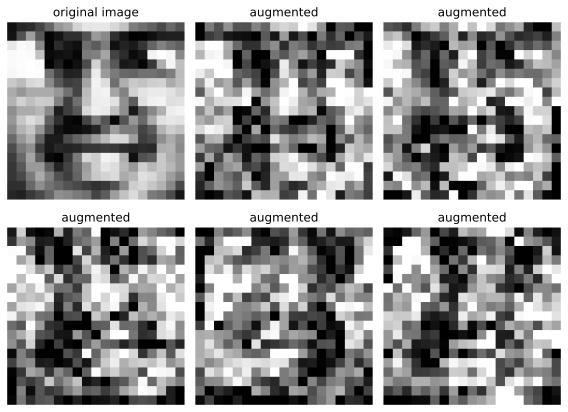

In [142]:
def show_imgs(imgs, nc=3, titles=None):
    n = len(imgs)
    nr = (n + nc - 1) // nc
    plt.figure(figsize=(8, 6))
    for i in range(n):
        plt.subplot(nr, nc, i+1)
        plt.imshow(imgs[i], cmap='gray')
        plt.axis('off')
        if titles and i < len(titles):
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

img = trainI[9]  # pick one
img_tensor = torch.FloatTensor(img)
print(img_tensor.shape)

cnt = 0
imgs = [img]
for _ in range(5):
    aug_img = augmentation(img_tensor.permute(2, 0, 1))
    imgs.append(aug_img.permute(1, 2, 0)[..., 0].numpy())
    cnt += 1
    if cnt >= 5:
        break

# show the results
titles = ['original image', 'augmented', 'augmented', 'augmented', 'augmented', 'augmented']
show_imgs(imgs, nc=3, titles=titles)

The augmented images look similar to the original image, but contain small differences that the network can use to learn more about the class.

Now let's try training logistic regression with data augmentation. Instead sending the original X,Y data, we now transform it first.

In [143]:
# get augmented dataset
class AugmentedTensorDataset(TensorDataset):
    def __init__(self, *tensors, transform=None):
        super().__init__(*tensors)
        self.transform = transform

    def __getitem__(self, index):
        img = self.tensors[0][index]
        label = self.tensors[1][index]
        if self.transform:
            img = self.transform(img.permute(2, 0, 1)).permute(1, 2, 0)
        return img, label

# get dataset and dataloader
def get_aug_dataloader(t_input, t_output, batch_size=50, shuffle=False, transform=None):
    t_input, t_output = torch.as_tensor(t_input), torch.as_tensor(t_output)
    dataset = AugmentedTensorDataset(t_input, t_output, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader

Epoch 1: Train Loss: 0.4387, Train Acc: 0.8595, Val Loss: 0.1439, Val Acc: 0.9456
Epoch 2: Train Loss: 0.3320, Train Acc: 0.8772, Val Loss: 0.1247, Val Acc: 0.9542
Epoch 3: Train Loss: 0.3286, Train Acc: 0.8823, Val Loss: 0.1161, Val Acc: 0.9570
Epoch 4: Train Loss: 0.3270, Train Acc: 0.8825, Val Loss: 0.1206, Val Acc: 0.9470
Epoch 5: Train Loss: 0.3418, Train Acc: 0.8780, Val Loss: 0.1479, Val Acc: 0.9470
Epoch 6: Train Loss: 0.3238, Train Acc: 0.8739, Val Loss: 0.1108, Val Acc: 0.9527
Epoch 7: Train Loss: 0.3054, Train Acc: 0.8868, Val Loss: 0.2533, Val Acc: 0.9097
Epoch 8: Train Loss: 0.3031, Train Acc: 0.8858, Val Loss: 0.1168, Val Acc: 0.9556
Epoch 9: Train Loss: 0.3467, Train Acc: 0.8793, Val Loss: 0.1238, Val Acc: 0.9456
Epoch 10: Train Loss: 0.3034, Train Acc: 0.8818, Val Loss: 0.2422, Val Acc: 0.9140
Epoch 11: Train Loss: 0.3238, Train Acc: 0.8783, Val Loss: 0.1255, Val Acc: 0.9499
Epoch 12: Train Loss: 0.3197, Train Acc: 0.8833, Val Loss: 0.1655, Val Acc: 0.9355
Epoch 13: Tra

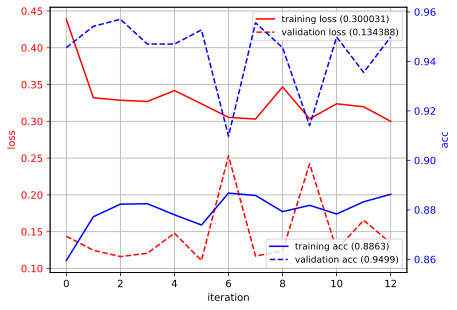

In [145]:
# initialize random seed
torch.manual_seed(4487)
np.random.seed(4487)
random.seed(4487)

# trying a simple logistic regression
model = MyModel(input_size=19*19, output_size=2, hidden_sizes=[])  # one layer model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_aug_dataloader(vtrainI, vtrainY, batch_size=50, shuffle=True, transform=augmentation)  # data loaders
val_loader = get_dataloader(validI, validY, batch_size=50)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10, optimizer=optimizer)

# test
plot_history2(history)
predY = model(torch.as_tensor(testI)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

Using data augmentation, the test accuracy improves!

Now train your best MLP from the previous section using data augmentation.
Try different per-pixel noise levels, and different options and combinations of them.  Hopefully you should be able to improve the accuracy!

Epoch 1: Train Loss: 0.3456, Train Acc: 0.8423, Val Loss: 0.1326, Val Acc: 0.9456
Epoch 2: Train Loss: 0.2327, Train Acc: 0.9052, Val Loss: 0.1060, Val Acc: 0.9542
Epoch 3: Train Loss: 0.2001, Train Acc: 0.9143, Val Loss: 0.1345, Val Acc: 0.9542
Epoch 4: Train Loss: 0.1763, Train Acc: 0.9293, Val Loss: 0.0960, Val Acc: 0.9585
Epoch 5: Train Loss: 0.1737, Train Acc: 0.9275, Val Loss: 0.0880, Val Acc: 0.9613
Epoch 6: Train Loss: 0.1578, Train Acc: 0.9374, Val Loss: 0.0799, Val Acc: 0.9656
Epoch 7: Train Loss: 0.1520, Train Acc: 0.9398, Val Loss: 0.0821, Val Acc: 0.9642
Epoch 8: Train Loss: 0.1514, Train Acc: 0.9377, Val Loss: 0.0781, Val Acc: 0.9670
Epoch 9: Train Loss: 0.1369, Train Acc: 0.9447, Val Loss: 0.0672, Val Acc: 0.9713
Epoch 10: Train Loss: 0.1320, Train Acc: 0.9470, Val Loss: 0.0651, Val Acc: 0.9742
Epoch 11: Train Loss: 0.1340, Train Acc: 0.9495, Val Loss: 0.0610, Val Acc: 0.9728
Epoch 12: Train Loss: 0.1268, Train Acc: 0.9514, Val Loss: 0.0936, Val Acc: 0.9599
Epoch 13: Tra

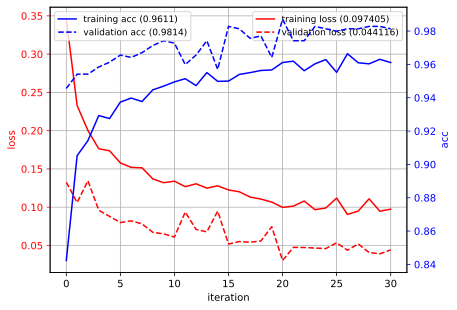

In [148]:
### INSERT YOUR CODE HERE ###
model_mlp = MyMLPModel(input_size=19*19, output_size=2, hidden_sizes=[512, 256, 128])
criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1e-3)

train_loader_mlp_aug = get_aug_dataloader(vtrainI, vtrainY, batch_size=64, shuffle=True, transform=augmentation)
val_loader_mlp_aug = get_dataloader(validI, validY, batch_size=64)
history_mlp = train_model(model_mlp, criterion_mlp, train_loader_mlp_aug, val_loader, total_epoch=100, patience=10, optimizer=optimizer_mlp)

plot_history2(history_mlp)
predY = model_mlp(torch.as_tensor(testI)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print(f"test accuracy: {acc}")

_Which type of augmentation improves the accuracy the most?  Why?_

- **INSERT YOUR ANSWER HERE**

# Test image
Now lets try your face detector on a real image.  Download the "nasa-small.png" image and put it in the same directory as your ipynb file.  The below code will load the image, crop out image patches and then extract features. (this may take a few minutes)

In [ ]:
fname = "nasa-small.png"

In [ ]:
# load image
testimg = skimage.io.imread(fname, as_gray=True)
print(testimg.shape)
plt.imshow(testimg, cmap='gray')

In [ ]:
# step size for the sliding window
step = 4

# extract window patches with step size of 4
patches = skimage.util.view_as_windows(testimg, (19,19), step=step)
psize = patches.shape
# collapse the first 2 dimensions
patches2 = patches.reshape((psize[0]*psize[1], psize[2], psize[3], 1))
print(patches2.shape)

# histogram equalize patches (improves contrast)
#newI = empty(patches2.shape)
#for i in range(patches2.shape[0]):
#    newI[i,:,:] = skimage.exposure.equalize_hist(patches2[i,:,:])
newI = patches2

Now predict using your classifier.  The extracted images are in `newI`.

In [ ]:
### YOUR CODE HERE


Now we we will view the results on the image.  Use the below code. `prednewY` is the vector of predictions.

In [ ]:
# reshape prediction to an image
imgY = prednewY.reshape(psize[0], psize[1])

# zoom back to image size
imgY2 = ndimage.interpolation.zoom(imgY, step, output=None, order=0)
# pad the top and left with half the window size
imgY2 = np.vstack((np.zeros((9, imgY2.shape[1])), imgY2))
imgY2 = np.hstack((np.zeros((imgY2.shape[0],9)), imgY2))
# pad right and bottom to same size as image
if (imgY2.shape[0] != testimg.shape[0]):
    imgY2 = np.vstack((imgY2, np.zeros((testimg.shape[0]-imgY2.shape[0], imgY2.shape[1]))))
if (imgY2.shape[1] != testimg.shape[1]):
    imgY2 = np.hstack((imgY2, np.zeros((imgY2.shape[0],testimg.shape[1]-imgY2.shape[1]))))

# show detections with image
#detimg = dstack(((0.5*imgY2+0.5)*testimg, 0.5*testimg, 0.5*testimg))
nimgY2 = 1-imgY2
tmp = nimgY2*testimg
detimg = np.dstack((imgY2+tmp, tmp, tmp))

# show it!
plt.figure(figsize=(9,9))
plt.subplot(2,1,1)
plt.imshow(imgY2, interpolation='nearest')
plt.title('detection map')
plt.subplot(2,1,2)
plt.imshow(detimg)
plt.title('image')
plt.axis('image')

_How did your face detector perform?_
- **INSERT YOUR ANSWER HERE**

You can try it on your own images.  The faces should all be around 19x19 pixels though.